In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree

In [7]:
data = pd.read_csv(r"D:\merged_flight_weather.csv")

In [8]:
def time_to_seconds(time_str):
    """Convert time in HHMMSS format to total seconds."""
    try:
        h, m, s = int(time_str[:2]), int(time_str[2:4]), int(time_str[4:])
        return h * 3600 + m * 60 + s
    except ValueError:
        return 0  # Handle invalid time strings

data['CRSDepTime'] = data['CRSDepTime'].astype(str).apply(time_to_seconds)

In [11]:
features = ['CRSArrTime', 'WindSpeedKmph', 'WindDirDegree', 'WeatherCode', 
            'precipMM', 'Visibilty', 'Pressure', 'Cloudcover', 'DewPointF', 
            'WindGustKmph', 'tempF', 'WindChillF', 'Humidity', 'Year', 
            'Quarter', 'Month', 'DayofMonth', 'CRSDepTime', 'DepDelayMinutes']
target = 'ArrDelayMinutes'

In [13]:
data = data.fillna(0)

In [14]:
X = data[features]
y = data[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
gbr = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)

In [21]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [23]:
y_pred = gbr.predict(X_test)

In [25]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [27]:
print(f"R² Score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.93
Mean Squared Error: 128.28
Root Mean Squared Error: 11.33


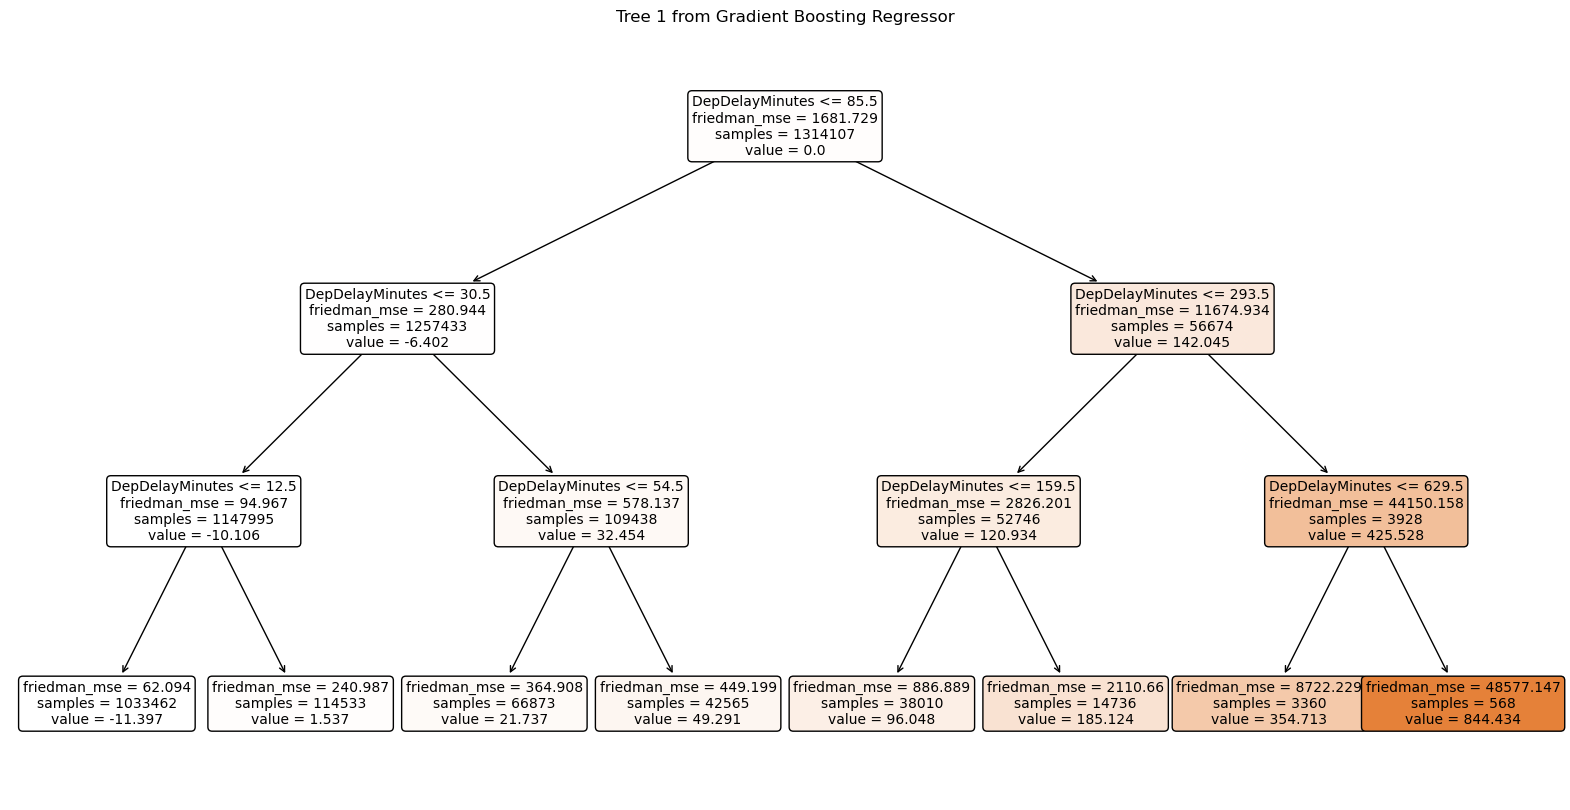

In [31]:
plt.figure(figsize=(20, 10))
estimator_index = 0
plot_tree(gbr.estimators_[estimator_index, 0], feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title(f"Tree {estimator_index + 1} from Gradient Boosting Regressor")
plt.show()